# 10.1 NumPy 数据处理（约2课时）

> **学习目标：** 掌握 NumPy 核心功能，包括数组创建、运算、索引、形状变换、统计与拼接分割。

---

## 一、NumPy 简介

**NumPy**（Numerical Python）是 Python 中最基础的科学计算库，几乎所有数据分析与机器学习框架（Pandas、Scikit-learn、TensorFlow、PyTorch）都依赖它。

### 为什么需要 NumPy？

| 对比项 | Python 原生 list | NumPy ndarray |
|--------|-----------------|---------------|
| 数据类型 | 可混合（任意类型） | 同构（单一类型） |
| 内存占用 | 大（每个元素独立对象） | 小（连续内存块） |
| 计算速度 | 慢（逐元素解释执行） | 快（C/Fortran 向量化） |
| 多维支持 | 嵌套 list，操作不便 | 原生支持 n 维数组 |

### ndarray 核心属性

```python
arr = np.array([[1,2,3],[4,5,6]])
arr.ndim    # 维度数（2）
arr.shape   # 形状 (2, 3)
arr.size    # 元素总数（6）
arr.dtype   # 数据类型（int64）
arr.itemsize # 每个元素字节数（8）
```


In [13]:
import numpy as np
print("NumPy 版本:", np.__version__)

# 创建一个 2×3 的 ndarray
arr = np.array([[1, 2, 3], [4, 5, 6]])
print("数组:")
print(arr)
print(f"ndim  (维度数): {arr.ndim}")
print(f"shape (形状)  : {arr.shape}")
print(f"size  (元素数): {arr.size}")
print(f"dtype (数据类型): {arr.dtype}")
print(f"itemsize (字节): {arr.itemsize}")


NumPy 版本: 1.23.5
数组:
[[1 2 3]
 [4 5 6]]
ndim  (维度数): 2
shape (形状)  : (2, 3)
size  (元素数): 6
dtype (数据类型): int32
itemsize (字节): 4


---
## 二、数组创建

NumPy 提供了多种创建数组的方式：

| 函数 | 说明 | 示例 |
|------|------|------|
| `np.array()` | 从列表/元组创建 | `np.array([1,2,3])` |
| `np.zeros()` | 全零数组 | `np.zeros((3,4))` |
| `np.ones()` | 全一数组 | `np.ones((2,3))` |
| `np.arange()` | 等差序列（类似 range） | `np.arange(0,10,2)` |
| `np.linspace()` | 等分序列 | `np.linspace(0,1,5)` |
| `np.random.rand()` | 均匀分布随机数 | `np.random.rand(3,3)` |
| `np.random.randn()` | 标准正态分布 | `np.random.randn(3,3)` |
| `np.eye()` | 单位矩阵 | `np.eye(3)` |
| `np.full()` | 指定值填充 | `np.full((2,2), 7)` |
| `np.empty()` | 未初始化数组 | `np.empty((2,2))` |


In [14]:
# ===== 数组创建演示 =====

# 1. 从列表创建
a = np.array([1, 2, 3])
print("np.array([1,2,3]) :", a)

# 2. 全零数组
z = np.zeros((2, 3))
print("np.zeros((2,3)) :\n", z)

# 3. 全一数组
o = np.ones((2, 3), dtype=float)
print("np.ones((2,3), dtype=float) :\n", o)

# 4. arange —— 等差序列 [0, 10), 步长 2
ar = np.arange(0, 10, 2)
print("np.arange(0, 10, 2) :", ar)

# 5. linspace —— 在 [0, 1] 等分 5 个点
ls = np.linspace(0, 1, 5)
print("np.linspace(0, 1, 5) :", ls)

# 6. 随机数
np.random.seed(42)
r = np.random.rand(2, 3)      # [0,1) 均匀分布
print("np.random.rand(2,3) :\n", r)

rn = np.random.randn(2, 3)    # 标准正态分布
print("np.random.randn(2,3) :\n", rn)

# 7. 单位矩阵
e = np.eye(3)
print("np.eye(3) :\n", e)

# 8. full —— 指定值填充
f = np.full((2, 2), 7)
print("np.full((2,2), 7) :\n", f)


np.array([1,2,3]) : [1 2 3]
np.zeros((2,3)) :
 [[0. 0. 0.]
 [0. 0. 0.]]
np.ones((2,3), dtype=float) :
 [[1. 1. 1.]
 [1. 1. 1.]]
np.arange(0, 10, 2) : [0 2 4 6 8]
np.linspace(0, 1, 5) : [0.   0.25 0.5  0.75 1.  ]
np.random.rand(2,3) :
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]
np.random.randn(2,3) :
 [[ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]]
np.eye(3) :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
np.full((2,2), 7) :
 [[7 7]
 [7 7]]


---
## 三、数组运算

### 3.1 元素级运算（Element-wise）

NumPy 的运算符默认是**逐元素**的，无需编写循环：

```python
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
a + b   # [5, 7, 9]
a * b   # [4, 10, 18]  注意：是逐元素相乘，不是矩阵乘法！
a ** 2  # [1, 4, 9]
```

常用数学函数（也是逐元素）：

| 函数 | 说明 |
|------|------|
| `np.sqrt(x)` | 平方根 |
| `np.exp(x)` | e 的 x 次方 |
| `np.log(x)` | 自然对数 |
| `np.abs(x)` | 绝对值 |
| `np.sin(x)` | 正弦 |
| `np.round(x, 2)` | 四舍五入 |


In [15]:
# ===== 元素级运算 =====
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("a      =", a)
print("b      =", b)
print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)      # 逐元素相乘
print("a / b  =", a / b)
print("a ** 2 =", a ** 2)
print("np.sqrt(a)  =", np.sqrt(a))
print("np.exp(a)   =", np.exp(a))
print("np.log(b)   =", np.log(b))


a      = [1 2 3 4]
b      = [10 20 30 40]
a + b  = [11 22 33 44]
a - b  = [ -9 -18 -27 -36]
a * b  = [ 10  40  90 160]
a / b  = [0.1 0.1 0.1 0.1]
a ** 2 = [ 1  4  9 16]
np.sqrt(a)  = [1.         1.41421356 1.73205081 2.        ]
np.exp(a)   = [ 2.71828183  7.3890561  20.08553692 54.59815003]
np.log(b)   = [2.30258509 2.99573227 3.40119738 3.68887945]


### 3.2 矩阵运算

```python
# 点积（向量内积）
np.dot(a, b)

# 矩阵乘法
np.matmul(A, B)    # 或 A @ B

# 矩阵转置
A.T

# 矩阵的逆
np.linalg.inv(A)
```


In [16]:
# ===== 矩阵运算 =====
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A =\n", A)
print("B =\n", B)

# 矩阵乘法：三种等价方式
print("np.dot(A, B)   =\n", np.dot(A, B))
print("np.matmul(A, B)=\n", np.matmul(A, B))
print("A @ B          =\n", A @ B)

# 转置
print("A.T =\n", A.T)

# 逆矩阵
print("np.linalg.inv(A) =\n", np.linalg.inv(A))

# 验证：A @ A^(-1) ≈ 单位矩阵
inv_A = np.linalg.inv(A)
print("A @ inv(A) =\n", np.round(A @ inv_A, 4))

# 行列式
print("np.linalg.det(A) =", np.linalg.det(A))


A =
 [[1 2]
 [3 4]]
B =
 [[5 6]
 [7 8]]
np.dot(A, B)   =
 [[19 22]
 [43 50]]
np.matmul(A, B)=
 [[19 22]
 [43 50]]
A @ B          =
 [[19 22]
 [43 50]]
A.T =
 [[1 3]
 [2 4]]
np.linalg.inv(A) =
 [[-2.   1. ]
 [ 1.5 -0.5]]
A @ inv(A) =
 [[1. 0.]
 [0. 1.]]
np.linalg.det(A) = -2.0000000000000004


### 3.3 广播机制（Broadcasting）详解 🌟

**广播**是 NumPy 最强大的特性之一：当两个数组形状不同时，NumPy 会自动"扩展"较小的数组使其形状兼容，从而实现逐元素运算。

#### 广播规则：
1. **规则一**：如果两个数组的维度数不同，较小的数组会在**左侧**补1维。
2. **规则二**：如果两个数组在某维度上大小不同，大小为 **1** 的维度会被**拉伸**以匹配另一个数组。
3. **规则三**：如果两个数组在某维度上大小不同且都不为1，则报错。

```
(3, 3)   op   (3,)    →  (3, 3) op (1, 3) → (3, 3) ✓
(3, 1)   op   (1, 4)  →  (3, 4) ✓
(2, 3)   op   (3,)    →  (2, 3) ✓
(2, 3)   op   (4,)    →  ✗ 报错
```


In [17]:
# ===== 广播机制演示 =====

# 案例1: 标量 + 数组
a = np.array([1, 2, 3])
print("a + 5 =", a + 5)  # 标量广播到 (3,)

# 案例2: (3,3) + (3,)
matrix = np.ones((3, 3))
row = np.array([10, 20, 30])
print("matrix + row:\n", matrix + row)  # row 广播到 (1,3) → (3,3)

# 案例3: (3,1) + (1,4)
col = np.array([[1], [2], [3]])  # shape (3,1)
rw  = np.array([[10, 20, 30, 40]])  # shape (1,4)
print("col + rw:\n", col + rw)  # 广播到 (3,4)

# 案例4: 实际应用 —— 每行减去均值
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
mean = data.mean(axis=1, keepdims=True)  # shape (3,1)
print("原始数据:\n", data)
print("行均值 (keepdims=True):\n", mean)
print("中心化 (减去行均值):\n", data - mean)

# 案例5: 计算每列的 z-score
col_mean = data.mean(axis=0, keepdims=True)  # (1,3)
col_std  = data.std(axis=0, keepdims=True)  # (1,3)
z = (data - col_mean) / col_std
print("列标准化 z-score:\n", np.round(z, 2))


a + 5 = [6 7 8]
matrix + row:
 [[11. 21. 31.]
 [11. 21. 31.]
 [11. 21. 31.]]
col + rw:
 [[11 21 31 41]
 [12 22 32 42]
 [13 23 33 43]]
原始数据:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
行均值 (keepdims=True):
 [[2.]
 [5.]
 [8.]]
中心化 (减去行均值):
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
列标准化 z-score:
 [[-1.22 -1.22 -1.22]
 [ 0.    0.    0.  ]
 [ 1.22  1.22  1.22]]


---
## 四、索引与切片

### 4.1 基本索引
```python
arr[0]       # 第0行
arr[1, 2]    # 第1行第2列
arr[:, 1]    # 所有行的第1列
arr[1:3, 0:2] # 行切片 [1,3)，列切片 [0,2)
```

### 4.2 布尔索引
```python
arr[arr > 5]   # 所有大于5的元素
```

### 4.3 花式索引（Fancy Indexing）
```python
arr[[0, 2, 4]]         # 第0,2,4行
arr[:, [1, 3]]         # 第1,3列
```


In [18]:
# ===== 索引与切片演示 =====
arr = np.arange(20).reshape(4, 5)
print("原始数组:\n", arr)

# 基本索引
print("arr[0]          :", arr[0])           # 第0行
print("arr[1, 2]       :", arr[1, 2])       # 第1行第2列
print("arr[:, 1]       :", arr[:, 1])       # 所有行第1列
print("arr[1:3, 0:2]  :\n", arr[1:3, 0:2]) # 行[1,3)，列[0,2)

print("\n" + "="*40)

# 布尔索引
print("arr[arr > 10]   :", arr[arr > 10])

# 组合条件
mask = (arr > 5) & (arr < 15)
print("arr[(arr>5) & (arr<15)] :", arr[mask])

print("\n" + "="*40)

# 花式索引
print("arr[[0, 2, 3]]  :\n", arr[[0, 2, 3]])    # 第0,2,3行
print("arr[:, [0, 2, 4]] :", arr[:, [0, 2, 4]])  # 第0,2,4列

# 花式索引 + 赋值（修改指定位置）
arr_copy = arr.copy()
arr_copy[[0, 1], [1, 2]] = 999  # (0,1)和(1,2)设为999
print("修改后:\n", arr_copy)


原始数组:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
arr[0]          : [0 1 2 3 4]
arr[1, 2]       : 7
arr[:, 1]       : [ 1  6 11 16]
arr[1:3, 0:2]  :
 [[ 5  6]
 [10 11]]

arr[arr > 10]   : [11 12 13 14 15 16 17 18 19]
arr[(arr>5) & (arr<15)] : [ 6  7  8  9 10 11 12 13 14]

arr[[0, 2, 3]]  :
 [[ 0  1  2  3  4]
 [10 11 12 13 14]
 [15 16 17 18 19]]
arr[:, [0, 2, 4]] : [[ 0  2  4]
 [ 5  7  9]
 [10 12 14]
 [15 17 19]]
修改后:
 [[  0 999   2   3   4]
 [  5   6 999   8   9]
 [ 10  11  12  13  14]
 [ 15  16  17  18  19]]


---
## 五、形状变换

| 函数 | 说明 | 是否共享内存 |
|------|------|-------------|
| `reshape()` | 改变形状 | 视图/副本（不确定） |
| `T` / `transpose()` | 转置 | 视图 ✓ |
| `flatten()` | 展平为一维 | 副本 ✗ |
| `ravel()` | 展平为一维 | 视图 ✓ |

> **视图 vs 副本**：视图共享内存（修改会影响原数组），副本拥有独立内存。


In [19]:
# ===== 形状变换演示 =====
arr = np.arange(12)
print("原始:", arr)

# reshape
a = arr.reshape(3, 4)
print("reshape(3, 4):\n", a)

# transpose
b = a.T
print("a.T:\n", b)

# flatten (返回副本)
c = a.flatten()
c[0] = 999
print(f"修改 flatten 后原数组 a[0,0] = {a[0,0]}（不变）")

# ravel (返回视图)
d = a.ravel()
d[0] = 888
print(f"修改 ravel 后原数组 a[0,0] = {a[0,0]}（变了！）")

# expand_dims / squeeze
e = np.expand_dims(a, axis=0)
print(f"expand_dims(a, 0) shape: {e.shape}")

f = np.squeeze(e)
print(f"squeeze(e) shape: {f.shape}")


原始: [ 0  1  2  3  4  5  6  7  8  9 10 11]
reshape(3, 4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
a.T:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
修改 flatten 后原数组 a[0,0] = 0（不变）
修改 ravel 后原数组 a[0,0] = 888（变了！）
expand_dims(a, 0) shape: (1, 3, 4)
squeeze(e) shape: (3, 4)


---
## 六、统计函数

| 函数 | 说明 | axis 参数 |
|------|------|-----------|
| `sum()` | 求和 | 0=列方向, 1=行方向 |
| `mean()` | 均值 | 同上 |
| `std()` | 标准差 | 同上 |
| `min()` / `max()` | 最小/最大值 | 同上 |
| `argmin()` / `argmax()` | 最小/最大值索引 | 同上 |
| `cumsum()` | 累积和 | 无 axis 时展平 |
| `cumprod()` | 累积积 | 同上 |
| `median()` | 中位数 | 同上 |
| `percentile()` | 百分位数 | 同上 |
| `corrcoef()` | 相关系数矩阵 | 无 |


In [20]:
# ===== 统计函数演示 =====
np.random.seed(0)
data = np.random.randn(5, 3) * 10 + 50  # 模拟 5个样本、3个特征
data = np.round(data, 1)
print("数据:\n", data)

print(f"全局求和: {data.sum()}")
print(f"全局均值: {data.mean():.2f}")
print(f"全局标准差: {data.std():.2f}")
print(f"全局最小值: {data.min()}, 最大值: {data.max()}")
print(f"最小值索引(argmin): {data.argmin()}, 最大值索引(argmax): {data.argmax()}")

print("\n按列统计 (axis=0):")
print("每列均值:", data.mean(axis=0))
print("每列标准差:", np.round(data.std(axis=0), 2))

print("\n按行统计 (axis=1):")
print("每行均值:", data.mean(axis=1))
print("每行最小值:", data.min(axis=1))

print("\n累积和:")
print("cumsum(axis=0):\n", np.round(data.cumsum(axis=0), 1))

print("\n百分位数:")
print("50%分位数(中位数):", np.median(data))
print("25%和75%分位数:", np.percentile(data, [25, 75]))

print("\n相关系数矩阵:")
print(np.round(np.corrcoef(data, rowvar=False), 2))


数据:
 [[67.6 54.  59.8]
 [72.4 68.7 40.2]
 [59.5 48.5 49. ]
 [54.1 51.4 64.5]
 [57.6 51.2 54.4]]
全局求和: 852.9000000000001
全局均值: 56.86
全局标准差: 8.42
全局最小值: 40.2, 最大值: 72.4
最小值索引(argmin): 5, 最大值索引(argmax): 3

按列统计 (axis=0):
每列均值: [62.24 54.76 53.58]
每列标准差: [6.74 7.18 8.47]

按行统计 (axis=1):
每行均值: [60.46666667 60.43333333 52.33333333 56.66666667 54.4       ]
每行最小值: [54.  40.2 48.5 51.4 51.2]

累积和:
cumsum(axis=0):
 [[ 67.6  54.   59.8]
 [140.  122.7 100. ]
 [199.5 171.2 149. ]
 [253.6 222.6 213.5]
 [311.2 273.8 267.9]]

百分位数:
50%分位数(中位数): 54.4
25%和75%分位数: [51.3  62.15]

相关系数矩阵:
[[ 1.    0.82 -0.64]
 [ 0.82  1.   -0.66]
 [-0.64 -0.66  1.  ]]


---
## 七、数组拼接与分割

### 拼接
| 函数 | 说明 |
|------|------|
| `np.concatenate()` | 沿指定轴拼接 |
| `np.vstack()` | 垂直拼接（等价于 axis=0） |
| `np.hstack()` | 水平拼接（等价于 axis=1） |
| `np.stack()` | 沿新轴堆叠（增加维度） |

### 分割
| 函数 | 说明 |
|------|------|
| `np.split()` | 等分分割 |
| `np.array_split()` | 不等分分割 |
| `np.vsplit()` | 垂直分割 |
| `np.hsplit()` | 水平分割 |


In [21]:
# ===== 拼接与分割 =====
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print("a =\n", a)
print("b =\n", b)

# concatenate
print("concatenate(axis=0):\n", np.concatenate([a, b], axis=0))
print("concatenate(axis=1):\n", np.concatenate([a, b], axis=1))

# vstack / hstack
print("vstack:\n", np.vstack([a, b]))
print("hstack:\n", np.hstack([a, b]))

# stack（增加新维度）
print("stack(axis=0) shape:", np.stack([a, b], axis=0).shape)
print("stack(axis=2) shape:", np.stack([a, b], axis=2).shape)

# ===== 分割 =====
arr = np.arange(12).reshape(3, 4)
print("\n原始:\n", arr)

print("split(3份, axis=0):\n", np.split(arr, 3, axis=0))
print("hsplit(2份):\n", np.hsplit(arr, 2))
print("array_split(不均分2份):\n", np.array_split(arr, 2, axis=0))


a =
 [[1 2]
 [3 4]]
b =
 [[5 6]
 [7 8]]
concatenate(axis=0):
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
concatenate(axis=1):
 [[1 2 5 6]
 [3 4 7 8]]
vstack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
hstack:
 [[1 2 5 6]
 [3 4 7 8]]
stack(axis=0) shape: (2, 2, 2)
stack(axis=2) shape: (2, 2, 2)

原始:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
split(3份, axis=0):
 [array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]
hsplit(2份):
 [array([[0, 1],
       [4, 5],
       [8, 9]]), array([[ 2,  3],
       [ 6,  7],
       [10, 11]])]
array_split(不均分2份):
 [array([[0, 1, 2, 3],
       [4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]


---
## 八、综合实践：NumPy 数组操作 + 可视化

结合 NumPy 运算与 Matplotlib 可视化，完成一个数据分析小项目。


In [22]:
import numpy as np
import matplotlib.pyplot as plt
# 设置 Matplotlib 中文字体以支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# ===== 实践：模拟传感器数据并进行统计分析 =====
np.random.seed(42)

# 模拟 3 个传感器，每个传感器记录 100 个时间步的数据
n_sensors = 3
n_steps = 100
time = np.linspace(0, 10, n_steps)

# 传感器1: 正弦波 + 噪声
sensor1 = np.sin(time * 2) * 10 + np.random.randn(n_steps) * 2
# 传感器2: 余弦波 + 噪声
sensor2 = np.cos(time * 1.5) * 8 + np.random.randn(n_steps) * 2.5
# 传感器3: 线性趋势 + 噪声
sensor3 = time * 3 + np.random.randn(n_steps) * 1.5

data = np.column_stack([sensor1, sensor2, sensor3])  # shape (100, 3)
print(f"数据形状: {data.shape}")

# 统计分析
print("\n各传感器统计:")
labels = ["传感器1(正弦)", "传感器2(余弦)", "传感器3(线性)"]
for i, label in enumerate(labels):
    col = data[:, i]
    print(f"  {label}: 均值={col.mean():.2f}, 标准差={col.std():.2f}, "
          f"最小值={col.min():.2f}, 最大值={col.max():.2f}")

# 相关系数矩阵
corr = np.corrcoef(data, rowvar=False)
print("\n相关系数矩阵:\n", np.round(corr, 3))


数据形状: (100, 3)

各传感器统计:
  传感器1(正弦): 均值=0.13, 标准差=7.28, 最小值=-12.83, 最大值=12.86
  传感器2(余弦): 均值=0.41, 标准差=5.86, 最小值=-11.04, 最大值=13.42
  传感器3(线性): 均值=15.10, 标准差=8.75, 最小值=-0.85, 最大值=30.94

相关系数矩阵:
 [[ 1.     0.165 -0.107]
 [ 0.165  1.     0.06 ]
 [-0.107  0.06   1.   ]]


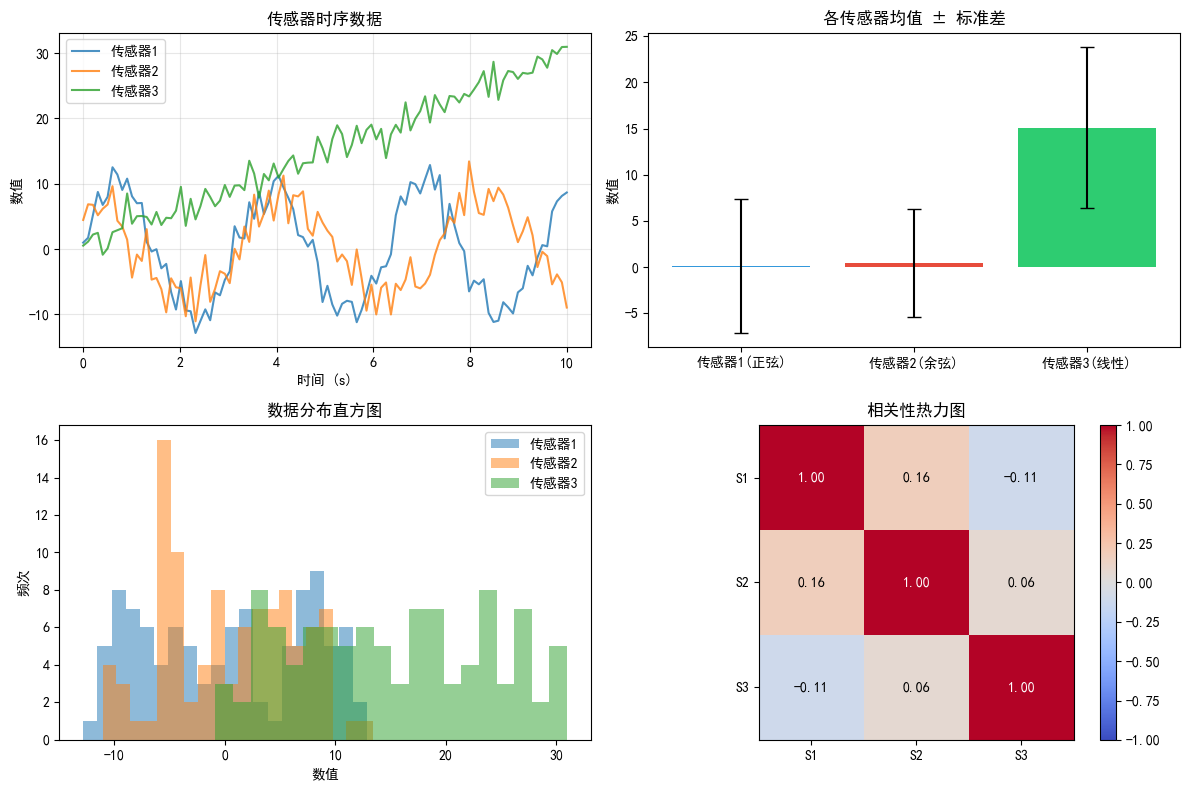

图表已保存为 10_1_numpy_practice.png


In [23]:
# ===== 可视化 =====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 子图1: 时序数据
ax1 = axes[0, 0]
ax1.plot(time, data[:, 0], label="传感器1", alpha=0.8)
ax1.plot(time, data[:, 1], label="传感器2", alpha=0.8)
ax1.plot(time, data[:, 2], label="传感器3", alpha=0.8)
ax1.set_title("传感器时序数据")
ax1.set_xlabel("时间 (s)")
ax1.set_ylabel("数值")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图2: 均值对比柱状图
ax2 = axes[0, 1]
means = data.mean(axis=0)
stds = data.std(axis=0)
bars = ax2.bar(labels, means, yerr=stds, capsize=5, color=["#3498db", "#e74c3c", "#2ecc71"])
ax2.set_title("各传感器均值 ± 标准差")
ax2.set_ylabel("数值")

# 子图3: 数据分布直方图
ax3 = axes[1, 0]
ax3.hist(data[:, 0], bins=20, alpha=0.5, label="传感器1")
ax3.hist(data[:, 1], bins=20, alpha=0.5, label="传感器2")
ax3.hist(data[:, 2], bins=20, alpha=0.5, label="传感器3")
ax3.set_title("数据分布直方图")
ax3.set_xlabel("数值")
ax3.set_ylabel("频次")
ax3.legend()

# 子图4: 相关性热力图
ax4 = axes[1, 1]
im = ax4.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax4.set_xticks([0, 1, 2])
ax4.set_yticks([0, 1, 2])
ax4.set_xticklabels(["S1", "S2", "S3"])
ax4.set_yticklabels(["S1", "S2", "S3"])
ax4.set_title("相关性热力图")
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax4)

plt.tight_layout()
plt.savefig("10_1_numpy_practice.png", dpi=100, bbox_inches="tight")
plt.show()
print("图表已保存为 10_1_numpy_practice.png")


---
## 📝 练习题

### 练习1：数组创建与运算
创建一个 5×5 的随机整数数组（范围 [1, 100]），计算：
- 每行的均值
- 每列的最大值及其索引
- 所有元素的标准差

### 练习2：广播机制
使用广播机制，为以下数据集的每一列减去该列的均值（中心化），然后计算中心化后的列标准差。验证中心化后均值是否接近 0。

### 练习3：布尔索引
生成一个 10×10 的随机数组（标准正态分布），使用布尔索引找出所有 `|x| > 2` 的元素，将其替换为 0。

### 练习4：数组拼接
创建两个数组 A（3×4）和 B（3×4），分别包含随机数据。然后将它们：
- 垂直拼接为 6×4 的数组
- 水平拼接为 3×8 的数组
- 将 A 的第一列替换为 B 的最后一列


In [24]:
# ===== 练习题参考答案 =====

# --- 练习1 ---
print("===== 练习1 =====")
np.random.seed(10)
ex1 = np.random.randint(1, 101, size=(5, 5))
print("数组:\n", ex1)
print("每行均值:", ex1.mean(axis=1))
print("每列最大值:", ex1.max(axis=0))
print("每列最大值索引:", ex1.argmax(axis=0))
print("全局标准差:", ex1.std())

# --- 练习2 ---
print("\n===== 练习2 =====")
np.random.seed(20)
ex2 = np.random.randn(100, 5) * 10 + 50
print("中心化前均值:", ex2.mean(axis=0))
centered = ex2 - ex2.mean(axis=0, keepdims=True)
print("中心化后均值:", np.round(centered.mean(axis=0), 10))
print("中心化后标准差:", np.round(centered.std(axis=0), 2))

# --- 练习3 ---
print("\n===== 练习3 =====")
np.random.seed(30)
ex3 = np.random.randn(10, 10)
count = np.sum(np.abs(ex3) > 2)
print(f"替换前: |x|>2 的元素数量: {count}")
ex3[np.abs(ex3) > 2] = 0
print(f"替换后: |x|>2 的元素数量: {np.sum(np.abs(ex3) > 2)}")

# --- 练习4 ---
print("\n===== 练习4 =====")
np.random.seed(40)
A = np.random.rand(3, 4)
B = np.random.rand(3, 4)
print("垂直拼接 shape:", np.vstack([A, B]).shape)
print("水平拼接 shape:", np.hstack([A, B]).shape)
A_mod = A.copy()
A_mod[:, 0] = B[:, -1]
print("A修改后:\n", np.round(A_mod, 2))


===== 练习1 =====
数组:
 [[10 16 65 29 90]
 [94 30  9 74  1]
 [41 37 17 12 55]
 [89 63 34 73 79]
 [50 52 55 78 70]]
每行均值: [42.  41.6 32.4 67.6 61. ]
每列最大值: [94 63 65 78 90]
每列最大值索引: [1 3 0 4 0]
全局标准差: 27.802043090391756

===== 练习2 =====
中心化前均值: [49.43370099 49.30060087 51.04251175 50.57184923 50.39365126]
中心化后均值: [ 0. -0.  0.  0. -0.]
中心化后标准差: [ 9.3  10.29 10.12  9.28  9.74]

===== 练习3 =====
替换前: |x|>2 的元素数量: 3
替换后: |x|>2 的元素数量: 0

===== 练习4 =====
垂直拼接 shape: (6, 4)
水平拼接 shape: (3, 8)
A修改后:
 [[0.9  0.06 0.79 0.29]
 [0.2  0.3  0.53 0.62]
 [0.96 0.69 0.98 0.6 ]]


---
## 📌 本节小结

| 知识点 | 核心API |
|--------|---------|
| 数组创建 | `array, zeros, ones, arange, linspace, random` |
| 元素级运算 | `+, -, *, /, **` + 通用函数 `np.sqrt, np.exp` |
| 矩阵运算 | `dot, matmul, @, linalg.inv, linalg.det` |
| 广播机制 | 自动扩展形状以匹配运算 |
| 索引切片 | 基本索引、布尔索引、花式索引 |
| 形状变换 | `reshape, T, flatten, ravel` |
| 统计函数 | `sum, mean, std, min, max, argmax, cumsum` |
| 拼接分割 | `concatenate, vstack, hstack, split` |

> ⭐ **关键提示**：NumPy 的核心优势是**向量化运算**和**广播机制**，能避免 Python 循环，大幅提升性能。在数据分析和机器学习中，务必优先使用 NumPy 向量化操作！
